# Load the Dataset

**Student Name:** Natali Bozhkova, 
**Student Number:** 2036556

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

hdf5_file = h5py.File('/content/drive/MyDrive/CLIP/LLD-icon-sharp.hdf5', 'r')

# Load Nessesary Models and Create Basis Functions

In [3]:
!pip install transformers

     |████████████████████████████████| 4.2 MB 11.7 MB/s 
     |████████████████████████████████| 84 kB 3.0 MB/s 
     |████████████████████████████████| 596 kB 47.3 MB/s 
     |████████████████████████████████| 6.6 MB 39.9 MB/s 
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 3.13
    Uninstalling PyYAML-3.13:
      Successfully uninstalled PyYAML-3.13


In [4]:
import os                                            #The code in this cell has been borrowed from the following notebook
import pandas as pd                                  #https://colab.research.google.com/drive/1OirXmWclTwbXvdlgRktSNKj3b-xDKBLC?usp=sharing
import numpy as np
from PIL import Image
import requests
from tqdm import tqdm
import torch
import torch.nn.functional as F
from transformers import (
    VisionTextDualEncoderModel,
    AutoFeatureExtractor,
    AutoTokenizer,
    AutoProcessor, 
    CLIPProcessor, 
    CLIPModel
)
from glob import glob
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns
sns.set_theme("notebook", font_scale=1.3)
from matplotlib.offsetbox import TextArea, DrawingArea, OffsetImage, AnnotationBbox


def plot_images(images):
    if isinstance(images, list) and len(images) > 1:
        fig, axes = plt.subplots(nrows=1, ncols=len(images), figsize=(12,8))
        for ax, im in zip(axes, images):
            ax.imshow(im)
            ax.grid(False)
    else:
        try:
            plt.imshow(images)
        except:
            plt.imshow(images[0])

    plt.grid(False)

def scatter_with_pca(texts, images):
    if not isinstance(images, list):
        images = [images]
      
    if not isinstance(texts, list):
        texts = [texts]

    text_embeds = embed_texts(texts, processor, model)
    image_embed = embed_images(images, processor, model)

    if torch.cuda.is_available():
        text_embeds = text_embeds.cpu()
        image_embed = image_embed.cpu()

    pca = PCA(n_components=2)
    X = torch.cat([text_embeds, image_embed], axis=0)
    X_2d = pca.fit_transform(X)

    X_texts = X_2d[:len(texts), :]
    X_images = X_2d[len(texts):, :]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.scatter(X_texts[0, 0], X_texts[0, 1], c="green", label="Highest cosine similarity label")

    if X_texts.shape[0] > 1:
      ax.scatter(X_texts[1:, 0], X_texts[1:, 1], c="darkorange", label="Text")
    
    for idx, image in enumerate(images):
        imagebox = OffsetImage(image, zoom=1)
        ab = AnnotationBbox(imagebox, (X_images[idx, 0], 1.01 * X_images[idx, 1]))
        ax.add_artist(ab)

    ax.scatter(X_images[:, 0], X_images[:, 1], c="royalblue", label="Image")
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

    ax.set_title("Cosine Similarities of Company Names with an Image in a Vector Space")

    plt.legend()

    for index, word in enumerate(texts):
        # annotate
        plt.annotate(word, xy=(X_texts[index, 0], X_texts[index, 1]))


def embed_texts(texts, processor, model):
    inputs = processor(text=texts, padding="longest")
    input_ids = torch.tensor(inputs["input_ids"])
    attention_mask = torch.tensor(inputs["attention_mask"])

    if torch.cuda.is_available():
      input_ids = input_ids.cuda()
      attention_mask = attention_mask.cuda()

    
    with torch.no_grad():    
        embeddings = model.get_text_features(
            input_ids=input_ids, attention_mask=attention_mask
        )
    return embeddings

def embed_images(images, processor, model):
    inputs = processor(images=images)
    pixel_values = torch.tensor(np.array(inputs["pixel_values"]))

    if torch.cuda.is_available():
      pixel_values = pixel_values.cuda()

    with torch.no_grad():
        embeddings = model.get_image_features(pixel_values=pixel_values)
    return embeddings

In [5]:
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32") #This code block is borrowed from the same notebook

if torch.cuda.is_available():
  model = model.cuda()

Downloading:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/577M [00:00<?, ?B/s]

In [6]:
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32") #This code block is borrowed from the same notebook

Downloading:   0%|          | 0.00/316 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/568 [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/842k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/512k [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/2.12M [00:00<?, ?B/s]

Downloading:   0%|          | 0.00/389 [00:00<?, ?B/s]

# Clean Data and Embed Texts and Images

In [7]:
## WE CLEANED THE NAMES OF COMPANIES BY FILTERING OUT THE DOMAIN NAMES OF ALL NON-ENGLISH SPEAKING COUNTRIES AND
## BY REMOVING ALL THE CHARACTERS AFTER THE FIRST DOT IN THE LABEL. THIS WILL MAKE IT POSSIBLE FOR US
## TO WORK WITH THEM AS COMPANY NAMES AND NOT AS DOMAIN NAMES. WE TOOK OUT ALL COMPANY
## NAMES WHICH CONSISTED OF DIGITS ONLY.

def get_company_names_and_images(N, offset=0): #N is the step size and offset is the starting point
  images = hdf5_file["data"]
  texts = hdf5_file["meta_data/names"]
  
  english_domains = [".au", ".ca", ".uk", ".com", ".net", ".org", ".ie", ".info", ".int"]
  company_names = []
  company_images = []

  stop = N+offset #stop point 

  if stop > len(images): #If step size is too big for an iteration, consider the last item available as a stop point
    stop = len(images)

  for i in range(offset, stop): #Here we're deciding on the size of data we want to start with
    name = texts[i].decode('UTF-8') #Decoding bytes into strings
    for domain in english_domains:
      if domain in name:
        name = name.partition(".")[0]
        if name.isdigit():
          continue

        image = np.moveaxis(images[i], 0, -1) #Moves the 0th axis of the image to the last place

        company_names.append(name)
        company_images.append(image)

  return company_names, company_images

company_names, company_images = get_company_names_and_images(1000)
print(f"{len(company_names)} indexes_of_company_names") #Displays how many names out of N were kept as english names which we will use later

663 indexes_of_company_names


In [8]:
import numpy as np

text_embeds = embed_texts(company_names, processor, model)
image_embeds = embed_images(company_images, processor, model)

#np.save.cpu()('/content/drive/MyDrive/CLIP/Image_embeds.npy', image_embeds) #Saves the images into a file so that computation is done faster next time
#np.save('/content/drive/MyDrive/CLIP/Text_embeds.npy', text_embeds) #Saves the texts into a file

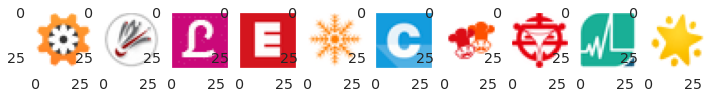

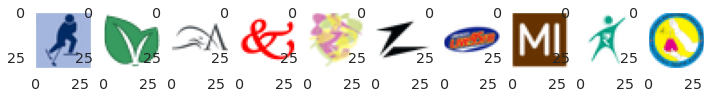

In [9]:
## We plotted some images out of curiosity and then chose which ones to experiment with
plot_images(company_images[30:40])
plot_images(company_images[120:130])

# An Example

Text(0.5, 1.0, 'livetvgr')

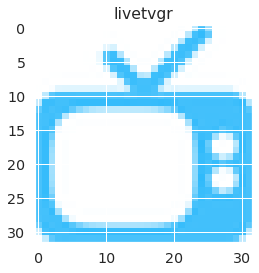

In [10]:
test_sample_id = 10 #Let's say we want to see whether CLIP recognises the correct name corresponding to the 10th image in the dataset
plt.imshow(company_images[test_sample_id])
plt.title(company_names[test_sample_id])

In [11]:
similarities = F.cosine_similarity(image_embeds[test_sample_id], text_embeds) #We compute a similarity score between the test image and all the text labels

sim_dict = []
for text, s in zip(company_names, similarities):
    sim_dict.append({'name': text, 'score': s.item()})# We store the similarieties with the image of each name into a list of dictionaries

sim_dict_sorted = sorted(sim_dict, key=lambda x: x["score"], reverse=True)

original_name = company_names[test_sample_id] #Original name is the one corresponding to the test image
name_with_highest_similarity = sim_dict_sorted[0]['name'] #After sorting the list of dictionaries, we take the fisrt element as the one with the highest similarity score

top_5_names = list(map(lambda x: x["name"], sim_dict_sorted))[:5] #Here we can see which are the 5 most similar names

print(f"Original name: {original_name}")
print(f"Guessed name: {name_with_highest_similarity}")

Original name: livetvgr
Guessed name: tvweb


In [12]:
#With this piece of code we show that the position of the original name is different when the list of names and their similarieties is ordered and when it is not
for idx, element in enumerate(sim_dict):
  if element["name"] == original_name:
    print(f"The original name is at the position {idx} in unsorted the unsorted list")
    break

for idx, element in enumerate(sim_dict_sorted):
  if element["name"] == original_name:
    print(f"The original name is at the position {idx} in the sorted list")
    break

The original name is at the position 10 in unsorted the unsorted list
The original name is at the position 5 in the sorted list


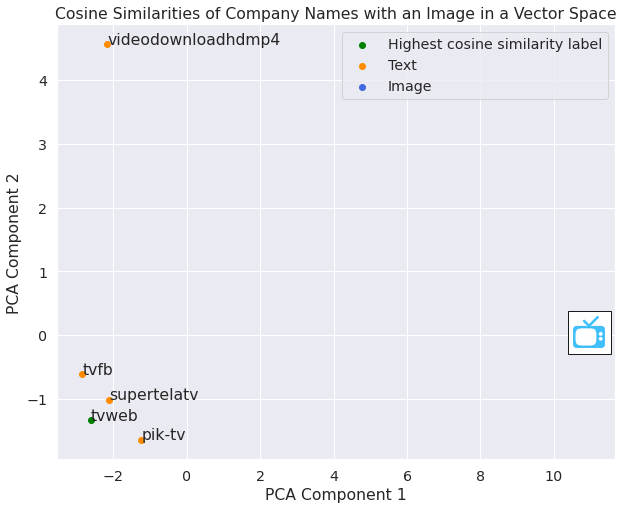

In [13]:
scatter_with_pca(top_5_names, company_images[test_sample_id]) #We can see the 5 most similar names to the depited picture and we can see the original name in green 

# Final Test of CLIP on LLD

In [18]:
#With this piece of code we show that the position of the original name is different when the list of names and their similarieties is ordered and when it is not
for idx, element in enumerate(sim_dict):
  if element["name"] == original_name:
    print(f"The original name is at the position {idx} in unsorted the unsorted list")
    break

for idx, element in enumerate(sim_dict_sorted):
  if element["name"] == original_name:
    print(f"The original name is at the position {idx} in the sorted list")
    break

The original name is at the position 10 in unsorted the unsorted list
The original name is at the position 5 in the sorted list


In [21]:
def test_clip(N, offset=0):
  company_names, company_images = get_company_names_and_images(N, offset)
    
  text_embeds = embed_texts(company_names, processor, model)
  image_embeds = embed_images(company_images, processor, model)

  top_100_count = 0

  for i in range(len(text_embeds)):
    original_name = company_names[i]
    similarities = F.cosine_similarity(image_embeds[i], text_embeds)

    sim_dict = []
    for text, s in zip(company_names, similarities):
        sim_dict.append({'name': text, 'score': s.item()})

    sim_dict_sorted = sorted(sim_dict, key=lambda x: x["score"], reverse=True)

    sorted_id = None
    for id, element in enumerate(sim_dict_sorted):
      if element["name"] == original_name:
        sorted_id = id
        break

    if sorted_id < 100:
      top_100_count += 1

  return top_100_count / len(text_embeds)

test_clip(1000, 1000)

0.43085880640465796

In [22]:
from tqdm.notebook import tqdm

step = 1000
#stop = 5000
stop = len(hdf5_file["data"])
percentages = [] #The % of each original name being in the top100 of the names with highest similarity scores
for i in tqdm(range(0, stop, step)): #We start at 0 and finish at the last company name in the dataset and we compute the clip_test function with a step size of 1000, 
  percentages.append(test_clip(step, i))                   #because this is approximately the maximum names this function can work with at a time, while we need 200k+
  #print(f"Starting from index {i} to index {i+step}")

print(f"Average {np.mean(percentages) * 100}") #This is the final result showing how often CLIP put the original name in the top 100 most similar to the image company names

  0%|          | 0/222 [00:00<?, ?it/s]

Average 46.748148174248755
